In [1]:
import os
import io
import pandas as pd
import numpy as np
from urllib import request
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
from urllib import request
from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.validation import check_is_fitted
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, accuracy_score



## Dataset Folder Path

In [2]:
############################### Define dataset paths (Change the Path Accordingly)
BASE_DATA_DIR = Path("/Users/ahmerjamil/Documents/UF Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples")
BASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Download Original Dataset (.TSV Files)

In [3]:
# !pip install gdown

In [4]:
# gdrive_folder_link = "https://drive.google.com/drive/folders/1wlXco9RhOnChKAKX9-gRwXhsg9s3hnWs?usp=sharing"
# os.system(f"gdown --folder {gdrive_folder_link} -O {BASE_DATA_DIR}")

## Loading the Dataset

In [5]:
############################ Function to load dataset
def load_dataset(filename: str, sep="\t") -> pd.DataFrame:
    file_path = BASE_DATA_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found. Please check dataset setup.")
    return pd.read_csv(file_path, sep=sep)

In [6]:
############################### Load train, validation, and test datasets
train_df = load_dataset("multimodal_train.tsv")
val_df   = load_dataset("multimodal_validate.tsv")
test_df  = load_dataset("multimodal_test_public.tsv")

In [7]:
############################### See shape
print("Train dataset shape      :", train_df.shape)
print("Validation dataset shape :", val_df.shape)
print("Test dataset shape       :", test_df.shape)

Train dataset shape      : (564000, 16)
Validation dataset shape : (59342, 16)
Test dataset shape       : (59319, 16)


In [8]:
###############################  seeing the number of columns
print("\nColumn names in train dataset:")
print(", ".join(train_df.columns))


Column names in train dataset:
author, clean_title, created_utc, domain, hasImage, id, image_url, linked_submission_id, num_comments, score, subreddit, title, upvote_ratio, 2_way_label, 3_way_label, 6_way_label


## Plotting

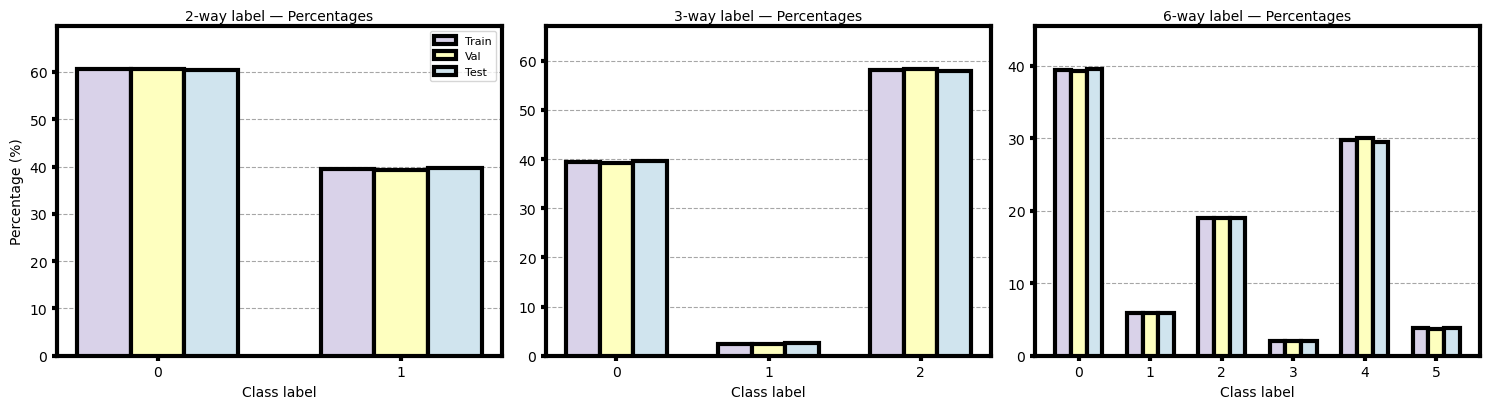

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Your bar colors ---
bar_colors = ["#d9d2e9", "#feffbf", "#d0e4ee"]  # Train, Val, Test (light lilac, yellow, light teal)

# --- Style (thick borders, dashed grid) ---
BAR_EDGE_COLOR  = "black"
BAR_EDGE_WIDTH  = 3
AX_BORDER_WIDTH = 3
TICK_WIDTH      = 3
GRID_KW = dict(axis="y", color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

LABEL_SPECS = {
    "2_way_label": [0, 1],
    "3_way_label": [0, 1, 2],
    "6_way_label": [0, 1, 2, 3, 4, 5],
}

def _percent_by_class(series, class_order):
    vc = series.value_counts(dropna=False)
    arr = np.array([vc.get(c, 0) for c in class_order], dtype=float)
    tot = arr.sum() if arr.sum() > 0 else 1.0
    return arr / tot * 100.0

def _style_axes(ax):
    for s in ax.spines.values():
        s.set_linewidth(AX_BORDER_WIDTH)
        s.set_edgecolor("black")
    ax.tick_params(axis="x", width=TICK_WIDTH)
    ax.tick_params(axis="y", width=TICK_WIDTH)

def plot_label_distributions_row(train_df, val_df, test_df, save_path="label_distributions_row.png"):
    """One row with 3 panels: (2-way, 3-way, 6-way). Bars = Train/Val/Test percentages with custom colors."""
    splits = {"Train": train_df, "Val": val_df, "Test": test_df}
    split_names = list(splits.keys())  # ["Train","Val","Test"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
    titles = {"2_way_label": "2-way label — Percentages",
              "3_way_label": "3-way label — Percentages",
              "6_way_label": "6-way label — Percentages"}

    for ax, (label_col, class_order) in zip(axes, LABEL_SPECS.items()):
        x = np.arange(len(class_order), dtype=float)
        w = 0.22
        ax.grid(**GRID_KW)

        ymax = 0.0
        for i, split_name in enumerate(split_names):
            df = splits[split_name]
            vals = _percent_by_class(df[label_col], class_order)
            ymax = max(ymax, vals.max())
            ax.bar(
                x + (i - 1)*w, vals, width=w,
                label=split_name,
                color=bar_colors[i],
                edgecolor=BAR_EDGE_COLOR, linewidth=BAR_EDGE_WIDTH,
                zorder=3
            )

        ax.set_xticks(x)
        ax.set_xticklabels(class_order, fontsize=10)
        ax.set_xlabel("Class label", fontsize=10)
        ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
        ax.set_title(titles[label_col], fontsize=10, pad=4)
        if label_col == "2_way_label":
            ax.set_ylabel("Percentage (%)", fontsize=10)
        _style_axes(ax)

    axes[0].legend(frameon=True, fontsize=8, loc="upper right")
    fig.tight_layout(w_pad=1.2)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Usage:
plot_label_distributions_row(train_df, val_df, test_df, save_path="label_distributions_row.png")


## Reducing the dataset into stratified train , val and test

In [10]:
###############################  will reduce the dataset to 100k train , 20k val and 20k test for better time 
###############################  efficiency and due to computing resource limitation


def stratified_sample(df, label_col, n, random_state=42):
    if n >= len(df):
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    vc = df[label_col].value_counts(normalize=True).sort_index()
    alloc = (vc * n).round().astype(int)

    diff = int(n - alloc.sum())
    if diff != 0:
        residuals = ((vc * n) - np.floor(vc * n)).sort_values(ascending=(diff < 0))
        for cls in residuals.index[:abs(diff)]:
            alloc[cls] += 1 if diff > 0 else -1
    rng = np.random.default_rng(random_state)
    parts = []
    for cls, k in alloc.items():
        cls_rows = df[df[label_col] == cls]
        k = min(k, len(cls_rows))  # safety
        if k > 0:
            parts.append(cls_rows.sample(n=k, random_state=int(rng.integers(0, 1e9))))
    out = pd.concat(parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out

def show_dist(df, name):
    d = df[LABEL_COL].value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"{name} {LABEL_COL} dist →", d)


In [11]:
LABEL_COL = next(c for c in ["6_way_label", "3_way_label", "2_way_label"] if c in train_df.columns)

N_TRAIN, N_VAL, N_TEST = 15000, 1500, 1500

train_small = stratified_sample(train_df, LABEL_COL, N_TRAIN, random_state=42)
val_small   = stratified_sample(val_df,   LABEL_COL, N_VAL,   random_state=43)
test_small  = stratified_sample(test_df,  LABEL_COL, N_TEST,  random_state=44)

print("Shapes:", train_small.shape, val_small.shape, test_small.shape)


show_dist(train_small, "train_small")
show_dist(val_small,   "val_small")
show_dist(test_small,  "test_small")


Shapes: (15000, 16) (1500, 16) (1500, 16)
train_small 6_way_label dist → {0: 0.394, 1: 0.059, 2: 0.19, 3: 0.021, 4: 0.298, 5: 0.038}
val_small 6_way_label dist → {0: 0.393, 1: 0.059, 2: 0.19, 3: 0.021, 4: 0.3, 5: 0.037}
test_small 6_way_label dist → {0: 0.396, 1: 0.059, 2: 0.191, 3: 0.021, 4: 0.295, 5: 0.039}


## Exploring the Text only train Dataset

In [12]:
display(train_small)
train_small.columns

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,cescyblue,waiting for the worthy to pick up the hammer,1.477651e+09,NaN,True,d9b8qh1,http://i.imgur.com/j41PLqj.jpg,59ofb4,NaN,3,psbattle_artwork,Waiting for the worthy to pick up the hammer,NaN,0,2,4
1,GeneralFelixBraxton,panicum you say,1.517503e+09,i.redd.it,True,7ujz0l,https://preview.redd.it/zxo219p4qmd01.jpg?widt...,NaN,1.0,2,fakealbumcovers,Panicum - You May Say,0.67,0,2,1
2,IrishWizard1,its not what it looks like,1.356878e+09,NaN,True,c7o96h0,http://i.imgur.com/JRXJo.jpg,15o37o,NaN,6,psbattle_artwork,It's not what it looks like!,NaN,0,2,4
3,boty_the_rapper,a chocolate covered onion found in philly,1.563917e+09,i.redd.it,True,cgyoqr,https://preview.redd.it/a2uh0hnce4c31.jpg?widt...,NaN,12.0,65,mildlyinteresting,A chocolate covered onion found in Philly,0.90,1,0,0
4,ctlasarce,takami watanabe mediterranean,1.569766e+09,i.redd.it,True,daviiz,https://preview.redd.it/1e2hrs87ijp31.png?widt...,NaN,3.0,48,fakealbumcovers,Takami Watanabe - Mediterranean,0.98,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,rnet85,a cat posing,1.408272e+09,m.imgur.com,True,2dsi3m,https://external-preview.redd.it/I9NX8uBpCNmKx...,NaN,5.0,6,photoshopbattles,PsBattle: A cat posing,0.71,1,0,0
14996,VideoHamster,plastic surgeon,1.362792e+09,NaN,True,c8sci5v,http://i.imgur.com/GXyamvx.jpg,19y27w,NaN,11,psbattle_artwork,plastic surgeon,NaN,0,2,4
14997,ruskeeblue,manafort strikes million bail deal with prosec...,1.512108e+09,politico.com,True,7gt3h6,https://external-preview.redd.it/ck6w04bhgK--B...,NaN,0.0,2,usnews,Manafort strikes $11 million bail deal with pr...,0.75,1,0,0
14998,Plokoon100,some dude with a hat taking a selfie while the...,1.483977e+09,i.redd.it,True,5myeyo,https://preview.redd.it/pjy95r09lp8y.jpg?width...,NaN,8.0,8,photoshopbattles,PsBattle: Some dude with a hat taking a selfie...,0.79,1,0,0


Index(['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id',
       'image_url', 'linked_submission_id', 'num_comments', 'score',
       'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label',
       '6_way_label'],
      dtype='object')

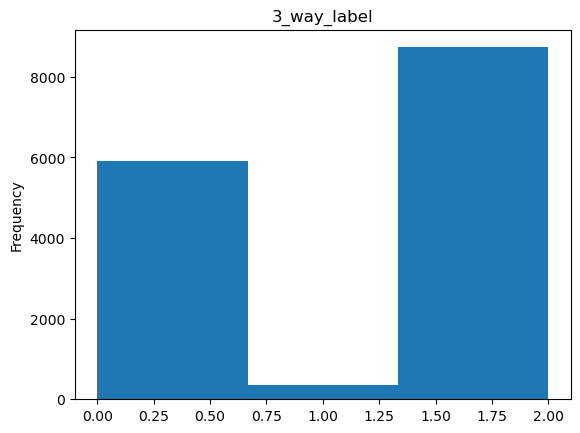

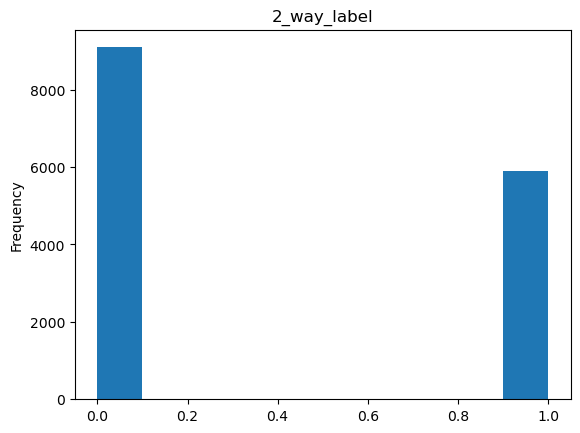

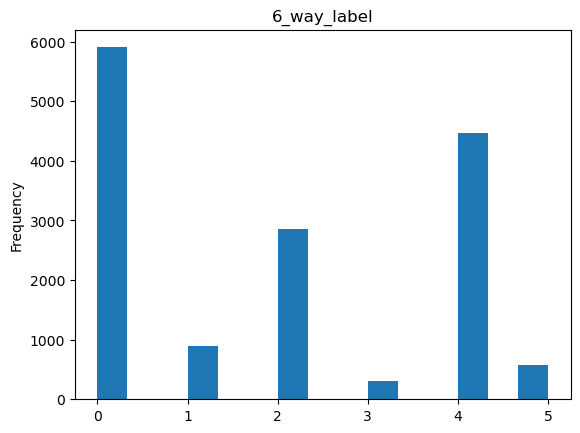

In [13]:

train_small["3_way_label"].plot(kind="hist", bins=3, title="3_way_label")
plt.show()

train_small["2_way_label"].plot(kind="hist", bins=10, title="2_way_label")
plt.show()

train_small["6_way_label"].plot(kind="hist", bins=15, title="6_way_label")
plt.show()


In [14]:
train_small["2_way_label"].value_counts()


2_way_label
0    9094
1    5906
Name: count, dtype: int64

In [15]:
train_small["3_way_label"].value_counts()


3_way_label
2    8732
0    5906
1     362
Name: count, dtype: int64

In [16]:
train_small["6_way_label"].value_counts()

6_way_label
0    5906
4    4464
2    2852
1     890
5     575
3     313
Name: count, dtype: int64

## Pre processing

In [17]:
############################### functions for preprocesisng 

###############################  configurations 
VERBOSE       = True
FAST_MODE     = True
HASHING_MODE  = False      # if True then no vocab, feature names not recoverable
RANDOM_STATE  = 42

############################### small grid over alpha (regularization)
ALPHA_GRID = [1e-4, 3e-4, 1e-3]

LABELS = ["2_way_label", "3_way_label", "6_way_label"]
C_GRID = [0.5, 1.0, 2.0]
NUMERIC_CORR_DROP = 0.95

############################### Leakage controls
DROP_SOURCE_COLUMNS = True
SOURCE_COLS = ["author", "domain", "subreddit", "id", "image_url", "linked_submission_id"]

############################### Text vectorizer configs
if FAST_MODE:
    WORD_MAXF = 100_000
    CHAR_MAXF = 100_000
else:
    WORD_MAXF = 200_000
    CHAR_MAXF = 200_000

TFIDF_WORD_ARGS = dict(
    analyzer="word", ngram_range=(1, 2), min_df=2, max_df=0.9,
    sublinear_tf=True, dtype=np.float32, max_features=WORD_MAXF
)
TFIDF_WORD_ARGS.update({
    "stop_words": "english",     # drop common stopwords (e.g., the, is, in)
    "strip_accents": "unicode",  # normalize accented chars
    "min_df": 5,                 # prune ultra-rare n-grams
    "max_df": 0.8,               # prune overly-common n-grams
})

TFIDF_CHAR_ARGS = dict(
    analyzer="char", ngram_range=(3, 5), min_df=2,
    sublinear_tf=True, dtype=np.float32, max_features=CHAR_MAXF
)
HASH_WORD_ARGS = dict(
    analyzer="word", ngram_range=(1, 2),
    alternate_sign=False, n_features=2**18, dtype=np.float32
)
HASH_CHAR_ARGS = dict(
    analyzer="char", ngram_range=(3, 5),
    alternate_sign=False, n_features=2**18, dtype=np.float32
)




In [18]:
############################### pretty printing
def p(msg):
    if VERBOSE:
        print(msg)

def header(msg):
    if VERBOSE:
        print("\n" + "="*len(msg))
        print(msg)
        print("="*len(msg))

def density(X):
    if sparse.issparse(X):
        total = X.shape[0]*X.shape[1]
        return (X.nnz / total) if total else 0.0
    total = X.size
    return float((X != 0).sum())/total if total else 0.0

def safe_has(df, col):
    return (col in df.columns)


In [19]:
###############################  Column dropped to drop columns taht lead to leakage
def drop_leaky_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if DROP_SOURCE_COLUMNS:
        present = [c for c in SOURCE_COLS if c in df.columns]
        if present:
            header("LEAK-SAFE: Dropping source-like columns")
            p(f"Dropping columns: {present}")
            df = df.drop(columns=present)
    print(df.columns)
    return df


In [20]:

############################### feature engineering 
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    header("STEP 1: Feature engineering & cleaning (returns a copy)")
    df = df.copy()
    # (clean_title)
    if not safe_has(df, "clean_title"):
        p("[WARN] 'clean_title' missing; creating empty strings.")
        df["clean_title"] = ""
    before_na = df["clean_title"].isna().sum()
    df["clean_title"] = df["clean_title"].fillna("").astype(str)
    p(f"[clean_title] NAs: {before_na} → {df['clean_title'].isna().sum()}")

    #  text stats
    df["title_len"]      = df["clean_title"].str.len().astype(np.int32)
    df["title_words"]    = df["clean_title"].str.split().map(len).astype(np.int32)
    df["title_qmarks"]   = df["clean_title"].str.count(r"\?").astype(np.int32)
    df["title_exclaims"] = df["clean_title"].str.count(r"!").astype(np.int32)
    caps    = df["clean_title"].str.count(r"[A-Z]")
    letters = df["clean_title"].str.count(r"[A-Za-z]").replace(0, 1)
    df["title_caps_ratio"] = (caps / letters).astype(np.float32)
    p(f"[clean_title] length quantiles: {df['title_len'].quantile([0,.25,.5,.75,.9,.99,1]).to_dict()}")

    # Indicators from possibly dropped columns
    # hasImage
    if safe_has(df, "hasImage"):
        n_hasImage = df["hasImage"].isna().sum()
        df["hasImage"] = df["hasImage"].fillna(False).astype(bool)
        p(f"[hasImage] NAs: {n_hasImage} → {df['hasImage'].isna().sum()}")
    else:
        p("[INFO] 'hasImage' missing; creating zeros.")
        df["hasImage"] = False

    # image_url → has_image_url
    # putting in a try catch block for the time when we drop our leakage columns 
    try:
        df["has_image_url"] = df["image_url"].notna().astype(np.int8)
        p(f"[has_image_url] positives: {df['has_image_url'].sum()}")
    except Exception:
        p("[INFO] 'image_url' missing; setting has_image_url=0.")
        df["has_image_url"] = 0

    # linked_submission_id = is_crosspost
    try:
        df["is_crosspost"] = df["linked_submission_id"].notna().astype(np.int8)
        p(f"[is_crosspost] positives: {df['is_crosspost'].sum()}")
    except Exception:
        p("[INFO] 'linked_submission_id' missing; setting is_crosspost=0.")
        df["is_crosspost"] = 0

    # Time features from created_utc
    if safe_has(df, "created_utc"):
        ts = pd.to_datetime(df["created_utc"], unit="s", errors="coerce")
        miss_time = ts.isna().sum()
        df["created_hour"] = ts.dt.hour.fillna(0).astype(np.int16)
        df["created_dow"]  = ts.dt.dayofweek.fillna(0).astype(np.int16)
        p(f"[created_utc] parse errors (NaT): {miss_time} → derived hour/dayofweek.")
    else:
        p("[INFO] 'created_utc' missing; creating zeros for created_hour/dow.")
        df["created_hour"] = 0
        df["created_dow"]  = 0

    # Numeric fill (if columns exist, otherwise create zeros)
    for c in ["num_comments", "score", "upvote_ratio"]:
        if safe_has(df, c):
            before = df[c].isna().sum()
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.float32)
            p(f"[{c}] NAs/invalid: {before} → {df[c].isna().sum()} | range=({df[c].min():.3f}, {df[c].max():.3f})")
        else:
            p(f"[INFO] '{c}' missing; creating zeros.")
            df[c] = 0.0

    p("Added engineered: title_len, title_words, title_qmarks, title_exclaims, title_caps_ratio, "
      "has_image_url, is_crosspost, created_hour, created_dow")
    return df

In [21]:

################################  numeric collinearity (train only) 
def numeric_collinearity_drop(train_proc: pd.DataFrame, numeric_cols, thr=NUMERIC_CORR_DROP):
    header("STEP 2: Numeric collinearity pruning (train only)")
    if len(numeric_cols) <= 1:
        p("Only one numeric column; nothing to drop.")
        return []
    try:
        corr = train_proc[numeric_cols].astype(float).corr().abs()
        s = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
        p("Top absolute correlations among numeric features:")
        for (a,b),v in s.sort_values(ascending=False).head(10).items():
            p(f"  {a:<20} ~ {b:<20} : {v:.3f}")
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if any(upper[c] > thr)]
        p(f"Drop (>|{thr}|): {to_drop}")
        return to_drop
    except Exception as e:
        p(f"[WARN] correlation check failed: {e}; skipping drop.")
        return []


In [22]:


################################ build ColumnTransformer 
def build_preprocessor(train_proc: pd.DataFrame):
    header("STEP 3: Build ColumnTransformer (text + nums; cats only if present & allowed)")
    # numeric block candidates (some may not exist; we added/created in FE)
    numeric_cols = [
        "num_comments", "score", "upvote_ratio",
        "title_len", "title_words", "title_qmarks", "title_exclaims", "title_caps_ratio",
        "has_image_url", "is_crosspost", "created_hour", "created_dow",
    ]
    # hasImage as int
    if safe_has(train_proc, "hasImage"):
        train_proc["hasImage"] = train_proc["hasImage"].astype(np.int8)
        numeric_cols.append("hasImage")

    # keep only those actually present
    numeric_cols = [c for c in numeric_cols if c in train_proc.columns]

    to_drop = numeric_collinearity_drop(train_proc, numeric_cols)
    numeric_final = [c for c in numeric_cols if c not in to_drop]
    p(f"Numeric kept: {numeric_final}")

    # text transformers
    if HASHING_MODE:
        txt_word = HashingVectorizer(**HASH_WORD_ARGS)
        txt_char = HashingVectorizer(**HASH_CHAR_ARGS)
        p("[Text] HashingVectorizer (no vocab fit)")
        p(f" word n_features={HASH_WORD_ARGS['n_features']} | char n_features={HASH_CHAR_ARGS['n_features']}")
    else:
        txt_word = TfidfVectorizer(**TFIDF_WORD_ARGS)
        txt_char = TfidfVectorizer(**TFIDF_CHAR_ARGS)
        p("[Text] TF-IDF configs:")
        p(f" word ngram_range={TFIDF_WORD_ARGS['ngram_range']}, max_features={TFIDF_WORD_ARGS['max_features']}")
        p(f" char ngram_range={TFIDF_CHAR_ARGS['ngram_range']}, max_features={TFIDF_CHAR_ARGS['max_features']}")

    transformers = [
        ("txt_word", txt_word, "clean_title"),
        ("txt_char", txt_char, "clean_title"),
        ("nums", Pipeline([
            ("to_float", FunctionTransformer(lambda X: X.astype(np.float32))),
            ("scale", StandardScaler(with_mean=False))
        ]), numeric_final),
    ]

    # onliy add categorical OHE if columns exist AND not dropped
    cat_candidates = [c for c in ["author","domain","subreddit"] if c in train_proc.columns]
    if cat_candidates:
        # keep but warn
        p(f"[INFO] Categorical columns available: {cat_candidates} (will be encoded)")
        transformers.insert(2, (
            "cats",
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=200, sparse_output=True),
            cat_candidates
        ))
    else:
        p("[INFO] No categorical source columns to encode (good for leak-safety).")

    preproc = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0
    )

    meta = {
        "numeric_cols_final": numeric_final,
        "dropped_numeric_cols": to_drop,
        "cat_cols": cat_candidates
    }
    return preproc, meta

In [23]:
################################ fit ONCE, transform all splits 
def prepare_feature_matrices(train_df, val_df, test_df):
    header("PREP: Fit preprocessor on TRAIN once; transform TRAIN/VAL/TEST")

    # feature engineering
    tr = add_engineered_features(train_df)
    va = add_engineered_features(val_df)
    te = add_engineered_features(test_df)

    # builds / fits 
    preproc, meta = build_preprocessor(tr)
    preproc.fit(tr)
    p("ColumnTransformer fitted on TRAIN.")

    # run diagnostics after the fit
    if not HASHING_MODE:
        try:
            tfidf_w = preproc.named_transformers_["txt_word"]
            tfidf_c = preproc.named_transformers_["txt_char"]
            p(f"[TF-IDF] word vocab size: {len(tfidf_w.vocabulary_)}")
            p(f"[TF-IDF] char vocab size: {len(tfidf_c.vocabulary_)}")
        except Exception as e:
            p(f"[WARN] Could not report TF-IDF sizes: {e}")
    if "cats" in preproc.named_transformers_:
        try:
            ohe = preproc.named_transformers_["cats"]
            for c, cats in zip(meta["cat_cols"], ohe.categories_):
                p(f"[OHE] {c}: {len(cats)} levels (incl. 'infrequent' bucket if created)")
        except Exception as e:
            p(f"[WARN] Could not report OHE categories: {e}")

    # transform
    X_tr = preproc.transform(tr)
    X_va = preproc.transform(va)
    X_te = preproc.transform(te)
    p(f"X_train shape={X_tr.shape}, density={density(X_tr):.6f}")
    p(f"X_valid shape={X_va.shape}, density={density(X_va):.6f}")
    p(f"X_test  shape={X_te.shape}, density={density(X_te):.6f}")
    p(f"Dropped numeric due to collinearity: {meta['dropped_numeric_cols']}")

    return (X_tr, X_va, X_te, tr, va, te, preproc, meta)

In [24]:
################################ feature-name recovery 
def recover_feature_names(preproc, meta):
    if HASHING_MODE:
        return None, "HashingVectorizer in use — feature names not available."
    try:
        names = []
        if "txt_word" in preproc.named_transformers_:
            names.extend([f"w:{t}" for t in preproc.named_transformers_["txt_word"].get_feature_names_out()])
        if "txt_char" in preproc.named_transformers_:
            names.extend([f"c:{t}" for t in preproc.named_transformers_["txt_char"].get_feature_names_out()])
        if "cats" in preproc.named_transformers_:
            ohe = preproc.named_transformers_["cats"]
            names.extend([f"cat:{t}" for t in ohe.get_feature_names_out(meta.get("cat_cols", []))])
        # numeric last
        names.extend([f"num:{t}" for t in meta.get("numeric_cols_final", [])])
        return np.array(names, dtype=object), None
    except Exception as e:
        return None, f"Could not recover feature names: {e}"



In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_confusion_matrix_single(
    cm_counts,
    title,
    class_names,
    save_path="confmat_single.png",
    annotate="count+percent",   # "count+percent" | "percent"
    cmap=None
):
    """
    Single confusion matrix with count and row-% annotations.
    cm_counts: raw counts (2D array)
    """
    cm_counts = np.array(cm_counts, dtype=float)
    row_sums = cm_counts.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_pct = np.divide(cm_counts, row_sums, where=row_sums != 0)

    if cmap is None:
        cmap = LinearSegmentedColormap.from_list(
            "light_blues", ["#e8f3ff", "#95c9ff", "#2a8df0"], N=256
        )

    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    im = ax.imshow(cm_pct, cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")

    ax.set_title(title, fontsize=18, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted", fontsize=14, fontweight="bold", labelpad=6)
    ax.set_ylabel("Actual",   fontsize=14, fontweight="bold", labelpad=6)

    ax.set_xticks(range(cm_counts.shape[1]))
    ax.set_yticks(range(cm_counts.shape[0]))
    ax.set_xticklabels([f"Class {c}" for c in class_names], rotation=45, ha="right", fontsize=11, fontweight="bold")
    ax.set_yticklabels([f"Class {c}" for c in class_names], fontsize=11, fontweight="bold")

    for s in ax.spines.values():
        s.set_linewidth(3.0)

    # annotate cells
    for r in range(cm_counts.shape[0]):
        for c in range(cm_counts.shape[1]):
            if row_sums[r, 0] == 0:
                txt = "0\n0.0%"
            else:
                pct = cm_pct[r, c] * 100
                if annotate == "percent":
                    txt = f"{pct:.1f}%"
                else:
                    cnt = int(cm_counts[r, c])
                    txt = f"{cnt}\n{pct:.1f}%"
            ax.text(c, r, txt, ha="center", va="center",
                    fontsize=11, fontweight="bold", color="black")

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Row fraction", fontsize=12, fontweight="bold")
    cbar.ax.tick_params(labelsize=11)
    cbar.outline.set_linewidth(2.0)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Modelling 


In [26]:
################################ model selection (SGDClassifier) , findin the right hyper parameters
def select_model_on_val(X_tr, y_tr, X_va, y_va):
    header("MODEL SELECTION (SGDClassifier hinge, early stopping)")
    best, best_clf = None, None
    for alpha in ALPHA_GRID:
        clf = SGDClassifier(
            loss="hinge",                # linear SVM
            alpha=alpha,                 # regularization
            class_weight="balanced",
            early_stopping=True,         # auto-stop on a held-out split
            validation_fraction=0.1,     # 10% of X train for ES
            n_iter_no_change=5,          # stop if no val improvement
            max_iter=5000,               # hard cap (usually stops earlier)
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_va)
        f1 = f1_score(y_va, pred, average="macro")
        acc = accuracy_score(y_va, pred)
        p(f"  alpha={alpha:<7} → macro-F1={f1:.4f} | acc={acc:.4f}")
        if (best is None) or (f1, acc) > (best["f1"], best["acc"]):
            best, best_clf = {"alpha": alpha, "f1": f1, "acc": acc}, clf
    p(f"Chosen: alpha={best['alpha']} (VAL macro-F1={best['f1']:.4f}, acc={best['acc']:.4f})")
    return best_clf, best

################################ retrain the mdoel on train + validation and run on test
def retrain_and_eval(best_clf, X_tr, y_tr, X_va, y_va, X_te, y_te, label, feature_names):
    header(f"FINAL TRAIN (train+val) and TEST for {label} [SGD hinge]")
    from scipy import sparse
    X_trva = sparse.vstack([X_tr, X_va], format="csr")
    y_trva = np.concatenate([y_tr, y_va])
    p(f"train+val matrix: {X_trva.shape}, density={density(X_trva):.6f}")

    final = SGDClassifier(
        loss="hinge",
        alpha=best_clf.get_params()["alpha"],
        class_weight="balanced",
        early_stopping=False,    # full train on train+val
        max_iter=5000,
        tol=1e-3,
        random_state=RANDOM_STATE
    )
    final.fit(X_trva, y_trva)

    pred = final.predict(X_te)
    macro = f1_score(y_te, pred, average="macro")
    acc = accuracy_score(y_te, pred)
    p(f"TEST macro-F1={macro:.4f} | acc={acc:.4f}")
    if VERBOSE:
        print(classification_report(y_te, pred, digits=4))

    # single confusion matrix (counts + row-%), saved per label 
    try:
        classes_sorted = np.unique(np.concatenate([y_tr, y_va, y_te]))
        cm_counts = confusion_matrix(y_te, pred, labels=classes_sorted)
        plot_confusion_matrix_single(
            cm_counts=cm_counts,
            title=label.replace("_label", "").replace("_", "-"),  # e.g., "2-way"
            class_names=classes_sorted,
            annotate="count+percent",
            save_path=f"confmat_{label}.png"
        )
    except Exception as e:
        p(f"[WARN] Could not plot confusion matrix for {label}: {e}")
    
    show_top_features(final, feature_names, top_k=25)  # works with TF-IDF
    return final, {"macro_f1": macro, "accuracy": acc}



In [27]:
################################# show top-features for explainibility 
def show_top_features(clf, feature_names, label_names=None, top_k=25):
    header("TOP FEATURES (by absolute weight)")
    if feature_names is None:
        p("Feature names unavailable. Skipping importance printout.")
        return
    try:
        coefs = clf.coef_
        if coefs.ndim == 1:
            coefs = coefs[np.newaxis, :]
        abs_max = np.max(np.abs(coefs), axis=0)
        top_idx = np.argsort(abs_max)[::-1][:top_k]
        p(f"Overall top {top_k} features:")
        for i, j in enumerate(top_idx, 1):
            p(f"{i:>3}. {feature_names[j]}  |weight|={abs_max[j]:.4f}")
    except Exception as e:
        p(f"[WARN] Could not compute top features: {e}")

## Running the modeling + data preprocesisg pipeline 


DATASET SHAPES (raw)
Train: (15000, 16) | Val: (1500, 16) | Test: (1500, 16)

PREP: Fit preprocessor on TRAIN once; transform TRAIN/VAL/TEST

STEP 1: Feature engineering & cleaning (returns a copy)
[clean_title] NAs: 0 → 0
[clean_title] length quantiles: {0.0: 1.0, 0.25: 19.0, 0.5: 35.0, 0.75: 57.0, 0.9: 79.0, 0.99: 160.01000000000022, 1.0: 479.0}
[hasImage] NAs: 0 → 0
[has_image_url] positives: 14958
[is_crosspost] positives: 4464
[created_utc] parse errors (NaT): 0 → derived hour/dayofweek.
[num_comments] NAs/invalid: 4464 → 0 | range=(0.000, 5336.000)
[score] NAs/invalid: 0 → 0 | range=(-46.000, 76632.000)
[upvote_ratio] NAs/invalid: 4464 → 0 | range=(0.000, 1.000)
Added engineered: title_len, title_words, title_qmarks, title_exclaims, title_caps_ratio, has_image_url, is_crosspost, created_hour, created_dow

STEP 1: Feature engineering & cleaning (returns a copy)
[clean_title] NAs: 0 → 0
[clean_title] length quantiles: {0.0: 1.0, 0.25: 19.0, 0.5: 33.0, 0.75: 57.0, 0.9: 78.0, 0.99: 

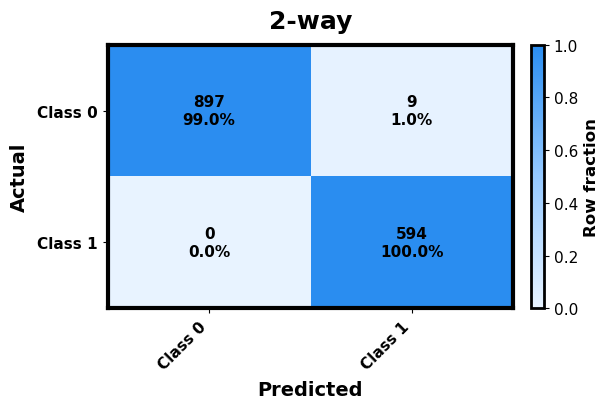


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. cat:subreddit_mildlyinteresting  |weight|=9.4478
  2. cat:subreddit_photoshopbattles  |weight|=9.1666
  3. cat:subreddit_nottheonion  |weight|=8.9042
  4. cat:subreddit_upliftingnews  |weight|=8.9042
  5. cat:subreddit_pareidolia  |weight|=4.8446
  6. cat:subreddit_infrequent_sklearn  |weight|=4.7451
  7. cat:subreddit_misleadingthumbnails  |weight|=4.5281
  8. cat:subreddit_fakehistoryporn  |weight|=4.4916
  9. cat:subreddit_fakealbumcovers  |weight|=4.3090
 10. cat:subreddit_propagandaposters  |weight|=4.2603
 11. cat:subreddit_theonion  |weight|=4.0534
 12. cat:subreddit_subredditsimulator  |weight|=4.0290
 13. cat:subreddit_savedyouaclick  |weight|=3.8586
 14. cat:subreddit_confusing_perspective  |weight|=3.8099
 15. cat:subreddit_psbattle_artwork  |weight|=3.5300
 16. cat:domain_nan  |weight|=3.5300
 17. num:upvote_ratio  |weight|=1.3714
 18. cat:domain_i.imgur.com  |weight|=1.0366
 19. w:people  |weight|=0.9432
 20.

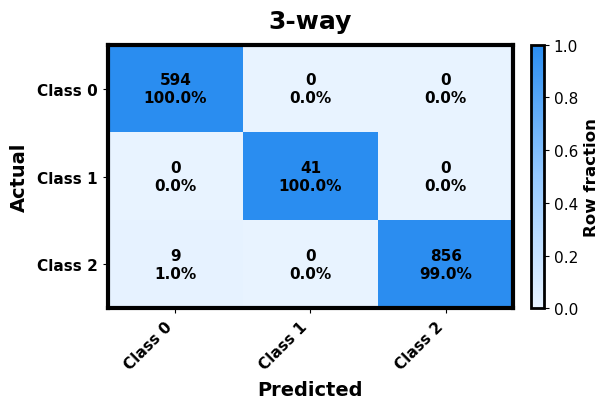


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. cat:subreddit_propagandaposters  |weight|=5.6606
  2. cat:subreddit_mildlyinteresting  |weight|=2.4688
  3. cat:subreddit_photoshopbattles  |weight|=2.3196
  4. cat:subreddit_nottheonion  |weight|=2.1122
  5. cat:subreddit_upliftingnews  |weight|=2.0702
  6. cat:domain_nan  |weight|=1.4409
  7. cat:subreddit_psbattle_artwork  |weight|=1.4409
  8. cat:subreddit_infrequent_sklearn  |weight|=1.4327
  9. cat:subreddit_pareidolia  |weight|=1.3962
 10. cat:subreddit_fakehistoryporn  |weight|=1.3217
 11. cat:subreddit_fakealbumcovers  |weight|=1.1499
 12. cat:subreddit_misleadingthumbnails  |weight|=1.1343
 13. cat:subreddit_subredditsimulator  |weight|=1.1291
 14. cat:subreddit_theonion  |weight|=1.1291
 15. cat:subreddit_savedyouaclick  |weight|=1.1083
 16. num:hasImage  |weight|=1.0776
 17. num:upvote_ratio  |weight|=1.0713
 18. cat:subreddit_confusing_perspective  |weight|=1.0147
 19. cat:author_infrequent_sklearn  |weight|=

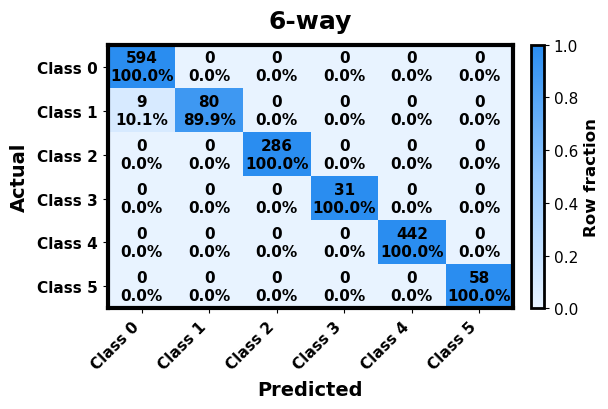


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. cat:subreddit_subredditsimulator  |weight|=9.8173
  2. cat:subreddit_propagandaposters  |weight|=8.8004
  3. cat:subreddit_fakealbumcovers  |weight|=8.2550
  4. cat:subreddit_savedyouaclick  |weight|=7.3788
  5. cat:subreddit_theonion  |weight|=6.6292
  6. cat:subreddit_pareidolia  |weight|=4.2193
  7. cat:subreddit_fakehistoryporn  |weight|=4.0071
  8. cat:subreddit_infrequent_sklearn  |weight|=3.9460
  9. cat:subreddit_mildlyinteresting  |weight|=3.4827
 10. cat:subreddit_photoshopbattles  |weight|=3.2776
 11. cat:subreddit_misleadingthumbnails  |weight|=3.2764
 12. cat:subreddit_upliftingnews  |weight|=3.1323
 13. cat:subreddit_nottheonion  |weight|=3.1067
 14. cat:subreddit_confusing_perspective  |weight|=2.7461
 15. num:hasImage  |weight|=2.7453
 16. cat:subreddit_psbattle_artwork  |weight|=2.6075
 17. cat:domain_nan  |weight|=2.6075
 18. num:num_comments  |weight|=2.3730
 19. num:upvote_ratio  |weight|=2.2201
 20. c

In [28]:

################################# RUN with all the columns 
for df_ in (train_small, val_small, test_small):
    for col in LABELS:
        df_[col] = pd.to_numeric(df_[col], errors="raise").astype(int)

header("DATASET SHAPES (raw)")
print("Train:", train_small.shape, "| Val:", val_small.shape, "| Test:", test_small.shape)

################################ one-time preprocessing
X_tr, X_va, X_te, tr_proc, va_proc, te_proc, preproc, meta = prepare_feature_matrices(train_small, val_small, test_small)

################################ feature names (may be None if hashing)
feat_names, warn_msg = recover_feature_names(preproc, meta)
if warn_msg:
    header("FEATURE NAME NOTICE")
    p(warn_msg)

################################ per label selection plus final training/testing
final_models = {}
metrics = {}
for label in LABELS:
    header(f"=== Label: {label} ===")
    y_tr = tr_proc[label].values
    y_va = va_proc[label].values
    y_te = te_proc[label].values

    best_clf, best = select_model_on_val(X_tr, y_tr, X_va, y_va)
    model, m = retrain_and_eval(best_clf, X_tr, y_tr, X_va, y_va, X_te, y_te, label, feat_names)

    final_models[label] = model
    metrics[label] = {"val_best": best, "test": m}

header("SUMMARY (per label)")
for k, v in metrics.items():
    print(f"{k}: VAL best {v['val_best']} | TEST → macro-F1={v['test']['macro_f1']:.4f}, acc={v['test']['accuracy']:.4f}")


### Analysis on data leakage

This analysis shows that if the model learns where the posts came from, it can reach 100 percent accuracy as the domains for fake news are almost always kept same, this also shows another issue, that our test and train or the test and train made available to us, it was not stratefied by these domains/ sources


## Retraining without author, subreddit and domain


LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id']
Index(['clean_title', 'created_utc', 'hasImage', 'num_comments', 'score',
       'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label'],
      dtype='object')

LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id']
Index(['clean_title', 'created_utc', 'hasImage', 'num_comments', 'score',
       'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label'],
      dtype='object')

LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id']
Index(['clean_title', 'created_utc', 'hasImage', 'num_comments', 'score',
       'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label'],
      dtype='object')

DATASET SHAPES (raw)
Train: (15000, 10) | Val: (1500, 10) | Test: (15

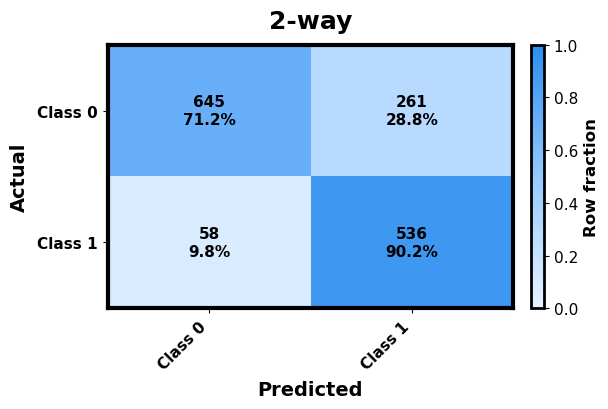


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. w:circa  |weight|=3.2002
  2. c:this   |weight|=2.8292
  3. w:poster  |weight|=2.5230
  4. c:his   |weight|=2.0008
  5. w:mrw  |weight|=1.7809
  6. c:ed   |weight|=1.7602
  7. w:bc  |weight|=1.6541
  8. w:th  |weight|=1.6159
  9. c: in   |weight|=1.6133
 10. c: me   |weight|=1.5764
 11. w:colourized  |weight|=1.4842
 12. w:ad  |weight|=1.4185
 13. c:me   |weight|=1.4087
 14. w:police  |weight|=1.3941
 15. w:sign  |weight|=1.3864
 16. w:unknown  |weight|=1.3755
 17. w:president trump  |weight|=1.3563
 18. c:in   |weight|=1.3463
 19. w:reveals  |weight|=1.3461
 20. c:you  |weight|=1.3436
 21. c: in  |weight|=1.3435
 22. c: ca  |weight|=1.3244
 23. w:ww  |weight|=1.3225
 24. w:nazi  |weight|=1.3194
 25. c: this  |weight|=1.3072

=== Label: 3_way_label ===

MODEL SELECTION (SGDClassifier hinge, early stopping)
  alpha=0.0001  → macro-F1=0.6312 | acc=0.7513
  alpha=0.0003  → macro-F1=0.6812 | acc=0.7820
  alpha=0.001   → macro

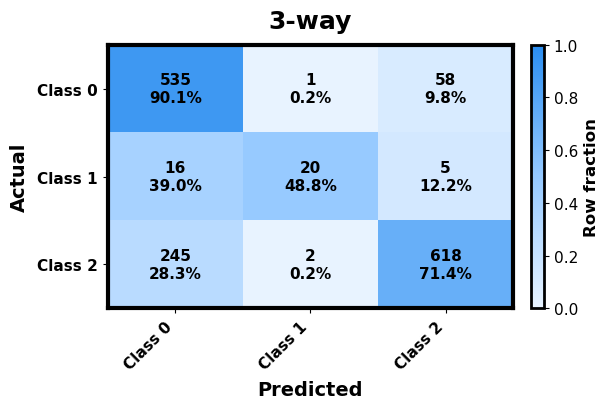


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. w:poster  |weight|=3.7228
  2. w:usa  |weight|=2.8117
  3. w:ussr  |weight|=2.6239
  4. w:circa  |weight|=2.3793
  5. c:you  |weight|=2.1871
  6. w:posters  |weight|=2.0969
  7. c:this   |weight|=2.0312
  8. w:cartoon  |weight|=2.0276
  9. w:modern  |weight|=2.0227
 10. w:united  |weight|=1.7014
 11. w:vote  |weight|=1.6879
 12. w:wwii  |weight|=1.6473
 13. num:hasImage  |weight|=1.5276
 14. w:war  |weight|=1.5001
 15. w:soviet  |weight|=1.4914
 16. c:his   |weight|=1.4863
 17. num:num_comments  |weight|=1.4820
 18. w:happy  |weight|=1.4557
 19. w:bc  |weight|=1.4544
 20. w:non  |weight|=1.3986
 21. c:anti  |weight|=1.3316
 22. w:police  |weight|=1.3063
 23. w:reagan  |weight|=1.2991
 24. w:struggle  |weight|=1.2909
 25. w:die  |weight|=1.2681

=== Label: 6_way_label ===

MODEL SELECTION (SGDClassifier hinge, early stopping)
  alpha=0.0001  → macro-F1=0.5690 | acc=0.7893
  alpha=0.0003  → macro-F1=0.5228 | acc=0.7127
  al

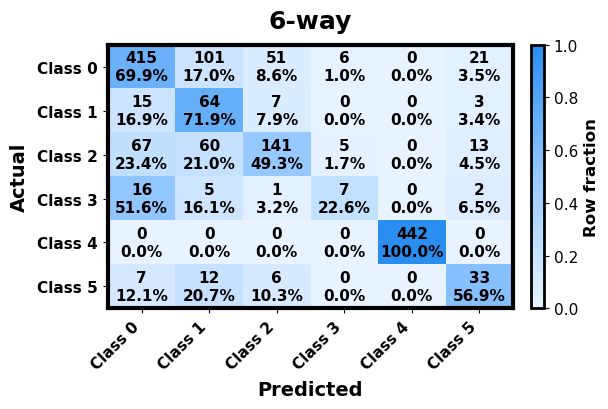


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. num:num_comments  |weight|=5.3891
  2. w:poster  |weight|=4.2554
  3. w:mrw  |weight|=3.5480
  4. w:til  |weight|=3.3188
  5. w:circa  |weight|=3.1761
  6. c: i   |weight|=2.9556
  7. w:usa  |weight|=2.9359
  8. w:cartoon  |weight|=2.6527
  9. c:this   |weight|=2.5991
 10. w:posters  |weight|=2.5672
 11. w:ussr  |weight|=2.4992
 12. num:upvote_ratio  |weight|=2.4823
 13. c:you  |weight|=2.4100
 14. w:quiz  |weight|=2.4048
 15. w:dad  |weight|=2.3663
 16. w:heres  |weight|=2.2649
 17. w:bc  |weight|=2.0803
 18. w:modern  |weight|=2.0480
 19. w:video  |weight|=2.0475
 20. c: a   |weight|=2.0275
 21. w:generation  |weight|=2.0133
 22. num:hasImage  |weight|=1.9854
 23. w:cable  |weight|=1.9342
 24. w:life  |weight|=1.9200
 25. w:youll  |weight|=1.8755

SUMMARY (per label)
2_way_label: VAL best {'alpha': 0.0001, 'f1': 0.8207720779044034, 'acc': 0.8273333333333334} | TEST → macro-F1=0.7862, acc=0.7873
3_way_label: VAL best {'a

In [29]:
################################ Drop the columns leading to leakgae
train_df = drop_leaky_columns(train_small)
val_df   = drop_leaky_columns(val_small)
test_df  = drop_leaky_columns(test_small)

################################# NOW RUN WITH SELECTED COLUMNS
for df_ in (train_df, val_df, test_df):
    for col in LABELS:
        df_[col] = pd.to_numeric(df_[col], errors="raise").astype(int)

header("DATASET SHAPES (raw)")
print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)

X_tr, X_va, X_te, tr_proc, va_proc, te_proc, preproc, meta = prepare_feature_matrices(train_df, val_df, test_df)

feat_names, warn_msg = recover_feature_names(preproc, meta)
if warn_msg:
    header("FEATURE NAME NOTICE")
    p(warn_msg)

final_models = {}
metrics = {}
for label in LABELS:
    header(f"=== Label: {label} ===")
    y_tr = tr_proc[label].values
    y_va = va_proc[label].values
    y_te = te_proc[label].values

    best_clf, best = select_model_on_val(X_tr, y_tr, X_va, y_va)
    model, m = retrain_and_eval(best_clf, X_tr, y_tr, X_va, y_va, X_te, y_te, label, feat_names)

    final_models[label] = model
    metrics[label] = {"val_best": best, "test": m}

header("SUMMARY (per label)")
for k, v in metrics.items():
    print(f"{k}: VAL best {v['val_best']} | TEST → macro-F1={v['test']['macro_f1']:.4f}, acc={v['test']['accuracy']:.4f}")



In [30]:
################################ analysis to see the number of features due to word grams and character grams 
parts = []
# word TF-IDF
if "txt_word" in preproc.named_transformers_:
    w = preproc.named_transformers_["txt_word"]
    n_w = len(getattr(w, "vocabulary_", {}))
    parts.append(("word_ngrams", n_w))
# char TF-IDF
if "txt_char" in preproc.named_transformers_:
    c = preproc.named_transformers_["txt_char"]
    n_c = len(getattr(c, "vocabulary_", {}))
    parts.append(("char_ngrams", n_c))
# OHE (if present)
if "cats" in preproc.named_transformers_:
    ohe = preproc.named_transformers_["cats"]
    n_cat = sum(len(cats) for cats in ohe.categories_)
    parts.append(("one_hot_cats", n_cat))
# numeric
n_num = len(meta.get("numeric_cols_final", []))
parts.append(("numeric", n_num))
total = sum(n for _, n in parts)
print("Feature blocks:", parts, "| total =", total)



Feature blocks: [('word_ngrams', 3251), ('char_ngrams', 81513), ('numeric', 12)] | total = 84776


## Removing all features and only training on title / clean title for comparision with multimodal approach

In [31]:
SOURCE_COLS = ["author", "domain", "subreddit", "id", "image_url", "linked_submission_id","upvote_ratio", "score", "num_comments", "created_utc", "hasImage"]


LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id', 'upvote_ratio', 'score', 'num_comments', 'created_utc', 'hasImage']
Index(['clean_title', 'title', '2_way_label', '3_way_label', '6_way_label'], dtype='object')

LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id', 'upvote_ratio', 'score', 'num_comments', 'created_utc', 'hasImage']
Index(['clean_title', 'title', '2_way_label', '3_way_label', '6_way_label'], dtype='object')

LEAK-SAFE: Dropping source-like columns
Dropping columns: ['author', 'domain', 'subreddit', 'id', 'image_url', 'linked_submission_id', 'upvote_ratio', 'score', 'num_comments', 'created_utc', 'hasImage']
Index(['clean_title', 'title', '2_way_label', '3_way_label', '6_way_label'], dtype='object')

DATASET SHAPES (raw)
Train: (15000, 5) | Val: (1500, 5) | Test: (1500, 5)

PREP: Fit preprocessor on TRAIN o

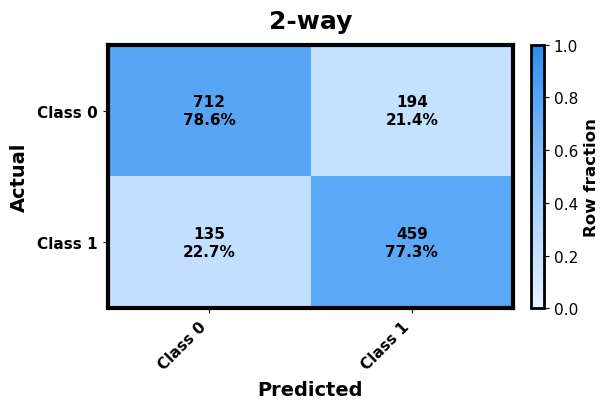


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. c:this   |weight|=3.7519
  2. w:circa  |weight|=2.9635
  3. c:his   |weight|=2.6811
  4. w:poster  |weight|=2.2889
  5. c:ed   |weight|=2.1440
  6. c: in   |weight|=1.8482
  7. c: this  |weight|=1.7566
  8. c:is   |weight|=1.7057
  9. c: ca  |weight|=1.6180
 10. c:you  |weight|=1.6169
 11. w:mrw  |weight|=1.6135
 12. w:fox  |weight|=1.5961
 13. c: in  |weight|=1.5960
 14. c: me   |weight|=1.5733
 15. c:my   |weight|=1.5723
 16. c:in   |weight|=1.5393
 17. w:sign  |weight|=1.4710
 18. w:president trump  |weight|=1.4504
 19. w:mushroom  |weight|=1.4320
 20. w:colourized  |weight|=1.4185
 21. w:girl  |weight|=1.4086
 22. w:corgi  |weight|=1.4030
 23. w:th  |weight|=1.3922
 24. c: thi  |weight|=1.3865
 25. w:looks like  |weight|=1.3505

=== Label: 3_way_label ===

MODEL SELECTION (SGDClassifier hinge, early stopping)
  alpha=0.0001  → macro-F1=0.6628 | acc=0.7553
  alpha=0.0003  → macro-F1=0.6832 | acc=0.7720
  alpha=0.001   

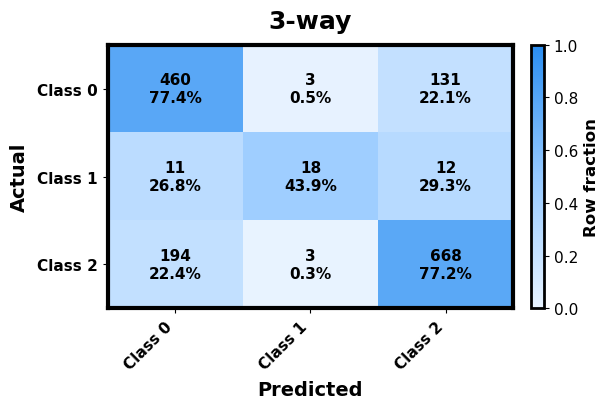


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. w:poster  |weight|=3.1410
  2. c:you  |weight|=2.8863
  3. w:usa  |weight|=2.7979
  4. w:ussr  |weight|=2.6975
  5. c:this   |weight|=2.3271
  6. w:cartoon  |weight|=2.0240
  7. w:modern  |weight|=1.9657
  8. w:circa  |weight|=1.9620
  9. w:posters  |weight|=1.7732
 10. w:vote  |weight|=1.7199
 11. c:his   |weight|=1.6931
 12. w:wwii  |weight|=1.6435
 13. w:united  |weight|=1.6418
 14. w:non  |weight|=1.5782
 15. w:cat  |weight|=1.5376
 16. w:soviet  |weight|=1.5135
 17. w:struggle  |weight|=1.4796
 18. w:reagan  |weight|=1.4793
 19. w:sign  |weight|=1.4438
 20. w:mexico  |weight|=1.4400
 21. w:meets  |weight|=1.4036
 22. w:ad  |weight|=1.3891
 23. w:dog  |weight|=1.3546
 24. w:police  |weight|=1.3460
 25. c: in   |weight|=1.3371

=== Label: 6_way_label ===

MODEL SELECTION (SGDClassifier hinge, early stopping)
  alpha=0.0001  → macro-F1=0.4417 | acc=0.6433
  alpha=0.0003  → macro-F1=0.4650 | acc=0.6233
  alpha=0.001   → 

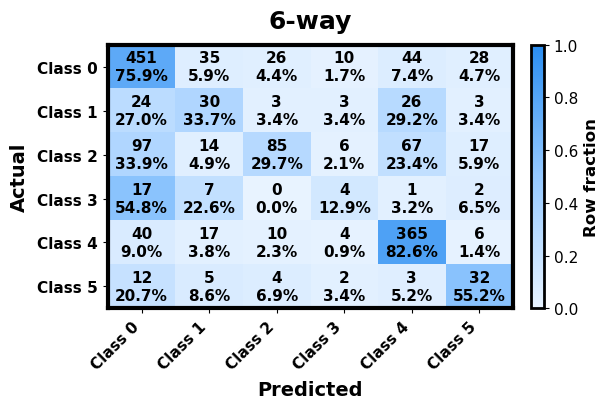


TOP FEATURES (by absolute weight)
Overall top 25 features:
  1. w:poster  |weight|=3.0321
  2. w:circa  |weight|=3.0081
  3. w:usa  |weight|=2.4299
  4. w:mrw  |weight|=2.3694
  5. w:bc  |weight|=2.3497
  6. w:ussr  |weight|=2.3106
  7. w:happy  |weight|=2.0956
  8. w:til  |weight|=2.0431
  9. w:dad  |weight|=2.0423
 10. c: i   |weight|=1.9758
 11. w:cartoon  |weight|=1.9335
 12. c: a   |weight|=1.9311
 13. w:video  |weight|=1.7524
 14. w:modern  |weight|=1.7166
 15. w:cable  |weight|=1.6310
 16. c:he   |weight|=1.6166
 17. w:quiz  |weight|=1.6049
 18. c:this   |weight|=1.5992
 19. w:heres  |weight|=1.5949
 20. w:colourized  |weight|=1.5203
 21. w:reveals  |weight|=1.4936
 22. c: th  |weight|=1.4889
 23. c:you  |weight|=1.4848
 24. w:sign  |weight|=1.4681
 25. w:police  |weight|=1.4389

SUMMARY (per label)
2_way_label: VAL best {'alpha': 0.0001, 'f1': 0.7996627656555201, 'acc': 0.808} | TEST → macro-F1=0.7742, acc=0.7807
3_way_label: VAL best {'alpha': 0.0003, 'f1': 0.6831858702296235

In [32]:
################################ Drop the columns leading to leakgae
train_df = drop_leaky_columns(train_small)
val_df   = drop_leaky_columns(val_small)
test_df  = drop_leaky_columns(test_small)

################################# NOW RUN WITH SELECTED COLUMNS
for df_ in (train_df, val_df, test_df):
    for col in LABELS:
        df_[col] = pd.to_numeric(df_[col], errors="raise").astype(int)

header("DATASET SHAPES (raw)")
print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)

X_tr, X_va, X_te, tr_proc, va_proc, te_proc, preproc, meta = prepare_feature_matrices(train_df, val_df, test_df)

feat_names, warn_msg = recover_feature_names(preproc, meta)
if warn_msg:
    header("FEATURE NAME NOTICE")
    p(warn_msg)

final_models = {}
metrics = {}
for label in LABELS:
    header(f"=== Label: {label} ===")
    y_tr = tr_proc[label].values
    y_va = va_proc[label].values
    y_te = te_proc[label].values

    best_clf, best = select_model_on_val(X_tr, y_tr, X_va, y_va)
    model, m = retrain_and_eval(best_clf, X_tr, y_tr, X_va, y_va, X_te, y_te, label, feat_names)

    final_models[label] = model
    metrics[label] = {"val_best": best, "test": m}

header("SUMMARY (per label)")
for k, v in metrics.items():
    print(f"{k}: VAL best {v['val_best']} | TEST → macro-F1={v['test']['macro_f1']:.4f}, acc={v['test']['accuracy']:.4f}")

